In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.impute import SimpleImputer


In [ ]:
#load the dataset
df=pd.read_csv('/content/titanic.csv')
print("Dataset loaded")

Dataset loaded


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
count=df.isnull()
print(count)

     PassengerId  Survived  Pclass   Name  ...  Ticket   Fare  Cabin  Embarked
0          False     False   False  False  ...   False  False   True     False
1          False     False   False  False  ...   False  False  False     False
2          False     False   False  False  ...   False  False   True     False
3          False     False   False  False  ...   False  False  False     False
4          False     False   False  False  ...   False  False   True     False
..           ...       ...     ...    ...  ...     ...    ...    ...       ...
886        False     False   False  False  ...   False  False   True     False
887        False     False   False  False  ...   False  False  False     False
888        False     False   False  False  ...   False  False   True     False
889        False     False   False  False  ...   False  False  False     False
890        False     False   False  False  ...   False  False   True     False

[891 rows x 12 columns]


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print("No of dup rows:",df.duplicated().sum())

No of dup rows: 0


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#create labelencoder
le=LabelEncoder()
#Apply labelencoding to the column sex
df['Sex']=le.fit_transform(df['Sex'])
df['Sex'].head()

,Sex
0,1
1,0
2,0
3,0
4,1


In [ ]:
#apply onehotencoding on embarked
df=pd.get_dummies(df,columns=['Embarked'])
df.head().['Embarked']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,False,True


In [ ]:
#create MinMaxScaler
scaler=MinMaxScaler()
#Normalize Age and Fare columns
df[['Age','Fare']]=scaler.fit_transform(df[['Age','Fare']])
df[['Age','Fare']].head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [ ]:
#create a new feature 'FamilySize' as SibSp+parch+1
df['FamilySize']=df['SibSp']+df['Parch']+1
print('FamilySize Feature Created')
display(df[["SibSp","Parch","FamilySize"]].head())

FamilySize Feature Created


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [ ]:
#create a new feature 'IsAlone' where 1 indicates traveling alone
df['IsAlone']=df['FamilySize'].apply(lambda x:1 if x==1 else 0)
print('IsAlone Feature Created')
display(df[["FamilySize","IsAlone"]].head())

IsAlone Feature Created


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


In [ ]:
#add 'FamilySize' and 'IsAlone' features to the dataset
df['FamilySize']=df['SibSp']+df['Parch']+1
df['IsAlone']=df['FamilySize'].apply(lambda x:1 if x==1 else 0)
print('FamilySize and IsAlone Features Added')

FamilySize and IsAlone Features Added


In [ ]:
#Outlier detection
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)


In [ ]:
print("dataset shape",df.shape)

dataset shape (891, 15)


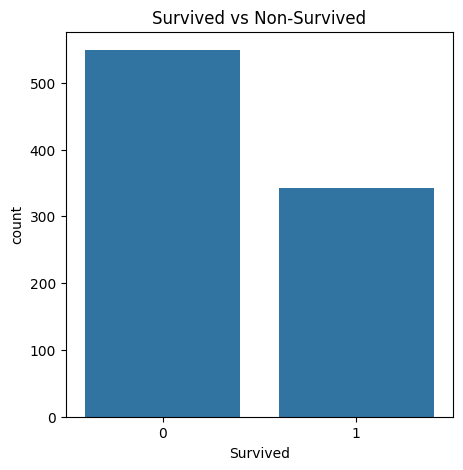

In [ ]:
#(Univariate Visualization)plot the count of passengers who Survived vs did not survived
plt.figure(figsize=(5,5))
sns.countplot(x='Survived',data=df)
plt.title('Survived vs Non-Survived')
plt.show()

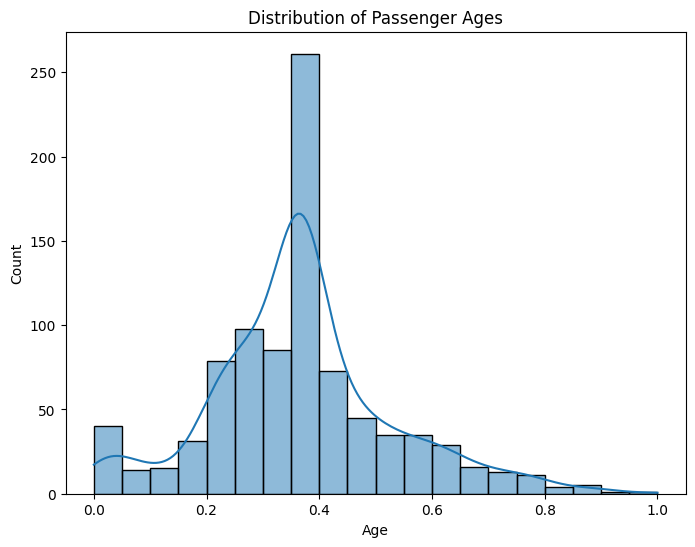

In [ ]:
#plot the distribution of passenger ages
plt.figure(figsize=(8,6))
sns.histplot(df['Age'],bins=20,kde=True)
plt.title('Distribution of Passenger Ages')
plt.show()

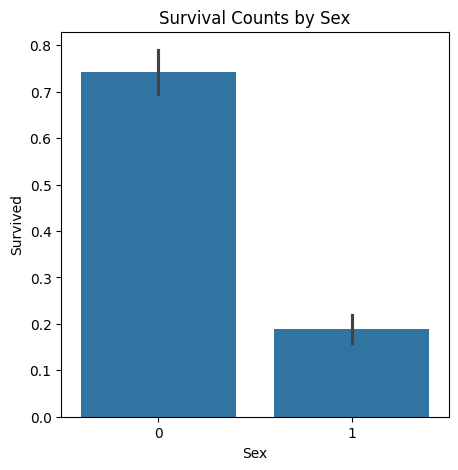

In [ ]:
#Bivariate Visualizations bar chart os Survival counts b Sex\
plt.figure(figsize=(5,5))
sns.barplot(x='Sex',y='Survived',data=df)
plt.title('Survival Counts by Sex')
plt.show()

In [ ]:
#drop columns Name and Ticket
drop_columns=['Name','Ticket']
df.drop(columns=drop_columns,inplace=True)
print('Columns dropped')

Columns dropped


In [ ]:
#Display side-by-side comparison of raw vs processed dataset(first 10 rows)
#Before vs After data comparison
bf=pd.read_csv('/content/titanic.csv')
print("Before PreProcessing")
display(bf.head(10))
print("After PreProcessing")
display(df.head(10))

Before PreProcessing


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


After PreProcessing


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,1,0,3,1,0.271174,1,0,0.014151,False,False,True,2,0
1,2,1,1,0,0.472229,1,0,0.139136,True,False,False,2,0
2,3,1,3,0,0.321438,0,0,0.015469,False,False,True,1,1
3,4,1,1,0,0.434531,1,0,0.103644,False,False,True,2,0
4,5,0,3,1,0.434531,0,0,0.015713,False,False,True,1,1
5,6,0,3,1,0.367921,0,0,0.016510,False,True,False,1,1
6,7,0,1,1,0.673285,0,0,0.101229,False,False,True,1,1
7,8,0,3,1,0.019854,3,1,0.041136,False,False,True,5,0
8,9,1,3,0,0.334004,0,2,0.021731,False,False,True,3,0
9,10,1,2,0,0.170646,1,0,0.058694,True,False,False,2,0
